## For each buffer:
- for the preceeding year, (overwinter_start) find when the last hotspot was detected.
- for the proceeding year, (overwinter_1) find when the first hotspot was detected.
- for the end of processing year, (overwinter_1_end), find when the last hotspot was detected.
- for the proceeding year, (overwinter_2), find when the first hotspot was detected
- overwinter_start = 2023
- overwinter_1 = 2024
- overwinter_1_end = 2024 fall
- overwinter_2 = 2025

## Using the dates and location of each hotspot, calculate:
- time between two hotspots
- distances between two hotspots
- distance from buffer edge
- distance from previous years fire boundary
- when lightning was detected +/- 72 hrs
- when snow melted for each buffer.
- when snow onset for each buffer.


## Files:

**buffers:** geometery = original perimeter, buffer_wkt = buffer geom. Both in wkt must to transformed to geodataframe when read in.
- overwinter_start: data/processed_wildfire_buffers/perims_2023_clipped_buffers.parquet
- overwinter_1 : data/processed_wildfire_buffers/perims_2024_clipped_buffers.parquet
- overwinter_2 : data/processed_wildfire_buffers/perims_2025_clipped_buffers.parquet

**hotspots:**
= 2023-2024



## workflow:
Look at 2024 hotspots, and 2023 buffer. If a hotspot occurs in a 2023 buffer, find the day of the buffer. Return a dataframe multiple rows for each and hotspot overlap, have column for hotspot geometry or ID, and date. Keep all columns from perimeter.

In [71]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
from find_hotspots_in_buffer import find_hotspots_in_buffers

## Step 1: Find hotspots in preceding-year buffers

For each hotspot year, spatially join to the buffer of the preceding year's fire perimeters.
- **2024 hotspots × 2023 buffers** → potential overwinter candidates from 2023 fires
- **2025 hotspots × 2024 buffers** → potential overwinter candidates from 2024 fires

Each result includes:
- `fire_perimeter_id` — which preceding-year perimeter the hotspot fell within
- `hotspot_year` — year of the hotspot
- `distance_to_perimeter` — Euclidean distance (m) from hotspot to original perimeter edge
- `distance_from_last_hotspot` — distance (m) from last hotspot observed *inside* the perimeter in the preceding year

In [14]:
# 2024 hotspots in 2023 buffers (overwinter_start → overwinter_1)
hotspots_in_buffers_2024 = find_hotspots_in_buffers(hotspot_year=2024, save=True)
hotspots_in_buffers_2024.head()

Loading 2024 hotspots and 2023 buffers...
Running spatial join (hotspots within buffers)...
Calculating distance_to_perimeter...
Finding last hotspot per perimeter in 2023...
Calculating distance_from_last_hotspot...
  23163 hotspots found in 2023 buffers


/Users/jgoldman/Documents/postdoc/overwintering/notebooks/../src/find_hotspots_in_buffer.py:171: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  return joined
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ACQ_DATE created as String field, though DateTime requested.
  ogr_write(
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'fire_perimeter_id' to 'fire_perim'
  ogr_write(
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'hotspot_year' to 'hotspot_ye'
  ogr_write(
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'distance_to_perimeter' to 'distance_t'

  saved hotspots_in_buffers_2024.shp and hotspots_in_buffers_2024.geojson


,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,DAYNIGHT,TYPE,source,year,geometry,fire_perimeter_id,hotspot_year,distance_to_perimeter,last_hotspot_date_in_perimeter,distance_from_last_hotspot
12,56.58211,-121.25147,331.50,0.34,0.56,2024-05-24,1930,N20,VIIRS,n,...,D,0.0,J1V-C2,2024,POINT (1290994.654 1297571.909),20,2024,0.000000,2023-10-13,148.563578
13,56.58226,-121.24985,297.66,0.35,0.57,2024-05-25,0920,N20,VIIRS,n,...,N,0.0,J1V-C2,2024,POINT (1291092.658 1297595.269),20,2024,0.000000,2023-10-13,209.763645
14,56.58244,-121.25571,304.08,0.35,0.57,2024-05-25,0920,N20,VIIRS,n,...,N,0.0,J1V-C2,2024,POINT (1290732.746 1297591.227),20,2024,0.000000,2023-10-13,200.141273
15,56.43418,-121.21347,335.31,0.48,0.48,2024-01-28,1948,N20,VIIRS,n,...,D,0.0,J1V-C2,2024,POINT (1294435.019 1281259.959),8,2024,173.999708,NaT,NaN
16,56.56920,-121.15707,334.22,0.40,0.37,2024-04-18,2045,N20,VIIRS,n,...,D,0.0,J1V-C2,2024,POINT (1296869.109 1296526.68),20,2024,0.000000,2023-10-13,6075.635666


In [15]:
# 2025 hotspots in 2024 buffers (overwinter_1_end → overwinter_2)
hotspots_in_buffers_2025 = find_hotspots_in_buffers(hotspot_year=2025, save=True)
hotspots_in_buffers_2025.head()

Loading 2025 hotspots and 2024 buffers...
Running spatial join (hotspots within buffers)...
Calculating distance_to_perimeter...
Finding last hotspot per perimeter in 2024...
Calculating distance_from_last_hotspot...
  2072 hotspots found in 2024 buffers
  saved hotspots_in_buffers_2025.shp and hotspots_in_buffers_2025.geojson


/Users/jgoldman/Documents/postdoc/overwintering/notebooks/../src/find_hotspots_in_buffer.py:171: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  return joined
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field ACQ_DATE created as String field, though DateTime requested.
  ogr_write(
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'fire_perimeter_id' to 'fire_perim'
  ogr_write(
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'hotspot_year' to 'hotspot_ye'
  ogr_write(
/Users/jgoldman/Documents/postdoc/overwintering/.venv/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'distance_to_perimeter' to 'distance_t'

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,DAYNIGHT,TYPE,source,year,geometry,fire_perimeter_id,hotspot_year,distance_to_perimeter,last_hotspot_date_in_perimeter,distance_from_last_hotspot
239,58.32583,-120.24101,297.06,0.38,0.36,2025-05-30,1020,N20,VIIRS,n,...,N,0.0,J1V-C2,2025,POINT (1336991.977 1495958.321),27,2025,234.938317,2024-06-01,25923.128879
240,58.32632,-120.24477,296.21,0.45,0.47,2025-05-11,0936,N20,VIIRS,n,...,N,0.0,J1V-C2,2025,POINT (1336768.009 1495994.839),27,2025,356.756321,2024-06-01,25909.475182
241,58.32650,-120.23809,305.82,0.42,0.38,2025-05-29,1039,N20,VIIRS,n,...,N,0.0,J1V-C2,2025,POINT (1337156.397 1496046.623),27,2025,251.305382,2024-06-01,26046.435375
242,58.32904,-120.23920,305.12,0.38,0.36,2025-05-30,1020,N20,VIIRS,n,...,N,0.0,J1V-C2,2025,POINT (1337068.586 1496323.383),27,2025,540.274116,2024-06-01,26296.073394
243,58.32977,-120.23574,311.63,0.42,0.38,2025-05-29,1039,N20,VIIRS,n,...,N,0.0,J1V-C2,2025,POINT (1337263.971 1496420.922),27,2025,552.474129,2024-06-01,26435.439608


## Step 2: Summary — hotspot counts per preceding-year perimeter

In [ ]:
def summarise(gdf, hotspot_year):
    fire_year = int(hotspot_year) - 1

    # Ensure date columns are datetime before any arithmetic
    gdf = gdf.copy()
    gdf["ACQ_DATE"] = pd.to_datetime(gdf["ACQ_DATE"])
    gdf["last_hotspot_date_in_perimeter"] = pd.to_datetime(gdf["last_hotspot_date_in_perimeter"])

    first_detection = (
        gdf.sort_values("ACQ_DATE")
        .groupby("fire_perimeter_id")
        .first()
        .reset_index()
        [["fire_perimeter_id", "ACQ_DATE", "distance_to_perimeter",
          "distance_from_last_hotspot", "last_hotspot_date_in_perimeter"]]
        .rename(columns={
            "ACQ_DATE": f"first_hotspot_{hotspot_year}",
            "distance_to_perimeter": "dist_to_perimeter_at_first",
            "distance_from_last_hotspot": "dist_from_last_hotspot",
            "last_hotspot_date_in_perimeter": f"last_hotspot_{fire_year}",
        })
    )

    counts = (
        gdf.groupby("fire_perimeter_id")
        .agg(
            n_hotspots_in_buffer=("ACQ_DATE", "count"),
            last_hotspot_in_buffer=("ACQ_DATE", "max"),
        )
        .reset_index()
    )

    summary = first_detection.merge(counts, on="fire_perimeter_id")

    summary["days_since_last_detection"] = (
        summary[f"first_hotspot_{hotspot_year}"] - summary[f"last_hotspot_{fire_year}"]
    ).dt.days

    summary = summary[[
        "fire_perimeter_id",
        f"last_hotspot_{fire_year}",
        f"first_hotspot_{hotspot_year}",
        "days_since_last_detection",
        "dist_to_perimeter_at_first",
        "dist_from_last_hotspot",
        "n_hotspots_in_buffer",
        "last_hotspot_in_buffer",
    ]]

    n_perims = len(summary)
    n_no_prev = summary[f"last_hotspot_{fire_year}"].isna().sum()
    print(f"{fire_year} fires → {hotspot_year} buffer hotspots")
    print(f"  {len(gdf)} hotspot matches across {n_perims} perimeters")
    print(f"  {n_no_prev} perimeters had no {fire_year} hotspot inside the original boundary")
    return summary

summary_2024 = summarise(hotspots_in_buffers_2024, hotspot_year=2024)
summary_2024

In [12]:
summary_2025 = summarise(hotspots_in_buffers_2025, "2025 hotspots in 2024 buffers")
summary_2025

2025 hotspots in 2024 buffers: 2072 hotspot matches across 9 perimeters


,fire_perimeter_id,n_hotspots,first_hotspot,last_hotspot,mean_dist_to_perimeter,mean_dist_from_last
0,8,1,2025-04-04,2025-04-04,61.988451,NaN
1,13,11,2025-04-05,2025-05-20,236.221953,556.756386
2,27,30,2025-05-02,2025-05-30,590.044506,26386.228440
3,28,6,2025-05-03,2025-05-17,152.690640,6114.883431
4,29,1,2025-01-27,2025-01-27,332.042364,834.131436
5,35,5,2025-05-09,2025-05-12,732.994181,NaN
6,40,340,2025-05-27,2025-06-01,151.132851,13537.791988
7,45,1651,2025-04-16,2025-06-01,156.383319,125023.242780
8,54,27,2025-05-31,2025-06-01,102.467606,1427.395920


# Analysis to look for overwinter fires based on hotspots and buffers. 

In [72]:
# read in hotspots
hotspots = gpd.read_file("../data/processed_hotspots/hotspots_clipped_all.shp")
hotspots.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,source,year,geometry
0,56.68786,-121.34752,322.47,0.51,0.41,2023/11/22 00:00:00,1053,N20,VIIRS,n,2,241.21,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728)
1,56.76530,-121.34372,326.79,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,2,282.72,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281)
2,56.76736,-121.33795,328.85,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,2,281.22,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774)
3,56.77076,-121.34865,336.76,0.48,0.65,2024/02/17 00:00:00,2154,N20,VIIRS,n,2,277.97,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355)
4,56.80400,-121.30665,340.56,0.47,0.48,2024/02/13 00:00:00,1948,N20,VIIRS,n,2,270.34,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708)


Get date column for hotspots

In [74]:
hotspots ['date']= pd.to_datetime(hotspots ['ACQ_DATE'])
hotspots ['year'] = hotspots ['date'].dt.year
hotspots ['month'] = hotspots ['date'].dt.month
hotspots ['day'] = hotspots ['date'].dt.day
hotspots.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,BRIGHT_T31,FRP,DAYNIGHT,TYPE,source,year,geometry,date,month,day
0,56.68786,-121.34752,322.47,0.51,0.41,2023/11/22 00:00:00,1053,N20,VIIRS,n,...,241.21,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728),2023-11-22,11,22
1,56.76530,-121.34372,326.79,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,...,282.72,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281),2024-02-23,2,23
2,56.76736,-121.33795,328.85,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,...,281.22,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774),2024-02-23,2,23
3,56.77076,-121.34865,336.76,0.48,0.65,2024/02/17 00:00:00,2154,N20,VIIRS,n,...,277.97,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355),2024-02-17,2,17
4,56.80400,-121.30665,340.56,0.47,0.48,2024/02/13 00:00:00,1948,N20,VIIRS,n,...,270.34,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708),2024-02-13,2,13


Only look at overwinter months

In [75]:
overwinter_months = [10, 11, 12, 1, 2, 3, 4, 5]
hs_offseason = hotspots[hotspots['date'].dt.month.isin(overwinter_months)]
hs_offseason.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,BRIGHT_T31,FRP,DAYNIGHT,TYPE,source,year,geometry,date,month,day
0,56.68786,-121.34752,322.47,0.51,0.41,2023/11/22 00:00:00,1053,N20,VIIRS,n,...,241.21,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728),2023-11-22,11,22
1,56.76530,-121.34372,326.79,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,...,282.72,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281),2024-02-23,2,23
2,56.76736,-121.33795,328.85,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,...,281.22,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774),2024-02-23,2,23
3,56.77076,-121.34865,336.76,0.48,0.65,2024/02/17 00:00:00,2154,N20,VIIRS,n,...,277.97,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355),2024-02-17,2,17
4,56.80400,-121.30665,340.56,0.47,0.48,2024/02/13 00:00:00,1948,N20,VIIRS,n,...,270.34,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708),2024-02-13,2,13


Get hotspots for 2023-2024 overwinter period

In [76]:
hs_winter_2023_24 = hs_offseason[hs_offseason['year'].isin([2023, 2024])]
hs_winter_2023_24.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,BRIGHT_T31,FRP,DAYNIGHT,TYPE,source,year,geometry,date,month,day
0,56.68786,-121.34752,322.47,0.51,0.41,2023/11/22 00:00:00,1053,N20,VIIRS,n,...,241.21,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728),2023-11-22,11,22
1,56.76530,-121.34372,326.79,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,...,282.72,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281),2024-02-23,2,23
2,56.76736,-121.33795,328.85,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,...,281.22,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774),2024-02-23,2,23
3,56.77076,-121.34865,336.76,0.48,0.65,2024/02/17 00:00:00,2154,N20,VIIRS,n,...,277.97,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355),2024-02-17,2,17
4,56.80400,-121.30665,340.56,0.47,0.48,2024/02/13 00:00:00,1948,N20,VIIRS,n,...,270.34,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708),2024-02-13,2,13


Look at the confidence column, the satelittle have different confidence values and I only want to select high confidence

In [87]:
# what is are the values in CONFIDENCE column?
hs_winter_2023_24['CONFIDENCE'].value_counts()

CONFIDENCE
n      38927
l       4676
h       3615
100     1183
94       177
       ...  
8          3
4          3
5          2
11         2
3          1
Name: count, Length: 102, dtype: int64

Normalizing confidence levels.. Modis uses values 0-100, while VIIRS uses values l,m,h

In [88]:
def normalize_confidence(val):
    # VIIRS categorical
    if val in ('h', 'high'):
        return 'high'
    elif val in ('n', 'nominal'):
        return 'medium'
    elif val in ('l', 'low'):
        return 'low'
    # MODIS numeric (stored as string)
    try:
        v = int(val)
        if v >= 80:
            return 'high'
        elif v >= 50:
            return 'medium'
        else:
            return 'low'
    except (ValueError, TypeError):
        return 'unknown'

hs_winter_2023_24['confidence_class'] = hs_winter_2023_24['CONFIDENCE'].apply(normalize_confidence)

# Sanity check
print(hs_winter_2023_24['confidence_class'].value_counts())

confidence_class
medium    39843
high       5894
low        5377
Name: count, dtype: int64


Filter to only medium and high confidence

In [89]:
hs_winter_2023_24 = hs_winter_2023_24[hs_winter_2023_24['confidence_class'].isin(['medium', 'high'])].copy()


Read in the buffers which will be used to search for hotspots in 2024

In [78]:
# read in buffers
buffers = pd.read_parquet("../data/processed_wildfire_buffers/perims_2023_clipped_buffers.parquet")
buffers.head()

,FIRE_NO,VERSION_NO,FIRE_YEAR,FIRE_CAUSE,FIRELABEL,SIZE_HA,SOURCE,TRACK_DATE,LOAD_DATE,FIRE_DATE,METHOD,FCODE,SHAPE,OBJECTID,AREA_SQM,FEAT_LEN,geometry,crs,buffer_wkt
23838,G80561,2.023060e+09,2023,Person,2023-G80561,3.6,2023 ROLLOVER,20230602,20230604,20230601,Non-corrected ground GPS,JA70003000,NaN,3180746.0,3.643531e+04,1090.5077,"POLYGON ((1294972.9061 1264534.2386, 1294970.9...",EPSG:3005,"POLYGON ((1293954.863103 1264476.491498, 12939..."
24119,G80052,2.023043e+09,2023,Person,2023-G80052,2.0,2023 ROLLOVER,20230428,20230428,20230416,Hand sketch of any type,JA70003000,NaN,3180728.0,2.009831e+04,582.3461,"POLYGON ((1301948.1719 1266513.373, 1301952.02...",EPSG:3005,"POLYGON ((1301066.994503 1266986.158781, 13011..."
24147,G80120,2.023043e+09,2023,Person,2023-G80120,1.5,2023 ROLLOVER,20230429,20230502,20230428,Non-corrected ground GPS,JA70003000,NaN,3180732.0,1.496113e+04,587.0283,"POLYGON ((1326551.0284 1266663.697, 1326573.46...",EPSG:3005,"POLYGON ((1325710.562105 1266038.638469, 13256..."
23813,G80190,2.023050e+09,2023,Person,2023-G80190,89.0,2023 ROLLOVER,20230504,20230510,20230503,Non-corrected ground GPS,JA70003000,NaN,3180739.0,8.900510e+05,7428.3175,"POLYGON ((1302268.9373 1271420.9943, 1302276.0...",EPSG:3005,"POLYGON ((1301068.371268 1271196.503269, 13010..."
23814,G80220,2.023051e+09,2023,Person,2023-G80220,6422.2,2023 ROLLOVER,20230513,20230513,20230501,Non-corrected airborne GPS,JA70003000,NaN,3180740.0,6.422172e+07,51424.1780,"POLYGON ((1366672.4458 1275195.5936, 1366700.3...",EPSG:3005,"POLYGON ((1359075.017904 1273224.417566, 13590..."


In [80]:
buffers_2023 = gpd.GeoDataFrame(buffers, geometry=gpd.GeoSeries.from_wkt(buffers["buffer_wkt"]), crs="EPSG:3005")

In [82]:
hs_winter_2023_24.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 51114 entries, 0 to 84610
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   LATITUDE    51114 non-null  float64       
 1   LONGITUDE   51114 non-null  float64       
 2   BRIGHTNESS  51114 non-null  float64       
 3   SCAN        51114 non-null  float64       
 4   TRACK       51114 non-null  float64       
 5   ACQ_DATE    51114 non-null  str           
 6   ACQ_TIME    51114 non-null  str           
 7   SATELLITE   51114 non-null  str           
 8   INSTRUMENT  51114 non-null  str           
 9   CONFIDENCE  51114 non-null  str           
 10  VERSION     51114 non-null  str           
 11  BRIGHT_T31  51114 non-null  float64       
 12  FRP         51114 non-null  float64       
 13  DAYNIGHT    51114 non-null  str           
 14  TYPE        34749 non-null  float64       
 15  source      51114 non-null  str           
 16  year        51114 n

Spatial join

In [90]:
join = gpd.sjoin(hs_winter_2023_24, buffers_2023, how='inner', predicate='within')
join.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,LOAD_DATE,FIRE_DATE,METHOD,FCODE,SHAPE,OBJECTID,AREA_SQM,FEAT_LEN,crs,buffer_wkt
13,56.58211,-121.25147,331.50,0.34,0.56,2024/05/24 00:00:00,1930,N20,VIIRS,n,...,20231004,20230513,Non-corrected airborne GPS,JA70003000,NaN,3180745.0,2.958429e+08,132173.5964,EPSG:3005,"POLYGON ((1278611.382523 1299999.333403, 12786..."
14,56.58226,-121.24985,297.66,0.35,0.57,2024/05/25 00:00:00,0920,N20,VIIRS,n,...,20231004,20230513,Non-corrected airborne GPS,JA70003000,NaN,3180745.0,2.958429e+08,132173.5964,EPSG:3005,"POLYGON ((1278611.382523 1299999.333403, 12786..."
15,56.58244,-121.25571,304.08,0.35,0.57,2024/05/25 00:00:00,0920,N20,VIIRS,n,...,20231004,20230513,Non-corrected airborne GPS,JA70003000,NaN,3180745.0,2.958429e+08,132173.5964,EPSG:3005,"POLYGON ((1278611.382523 1299999.333403, 12786..."
16,56.43418,-121.21347,335.31,0.48,0.48,2024/01/28 00:00:00,1948,N20,VIIRS,n,...,20230512,20230505,Non-corrected airborne GPS,JA70003000,NaN,3180741.0,2.947454e+07,38797.4344,EPSG:3005,"POLYGON ((1286315.999439 1280762.516832, 12863..."
17,56.56920,-121.15707,334.22,0.40,0.37,2024/04/18 00:00:00,2045,N20,VIIRS,n,...,20231004,20230513,Non-corrected airborne GPS,JA70003000,NaN,3180745.0,2.958429e+08,132173.5964,EPSG:3005,"POLYGON ((1278611.382523 1299999.333403, 12786..."


In [91]:
summary = join.groupby('FIRE_NO').agg(
    n_hotspot_detections = ('ACQ_DATE', 'count'),
    n_high_confidence    = ('confidence_class', lambda x: (x == 'high').sum()),
    satellites_detected  = ('SATELLITE', lambda x: list(x.unique())),
    n_satellites         = ('SATELLITE', 'nunique'),
    sources_detected     = ('source', lambda x: list(x.unique())),
    first_detection      = ('date', 'min'),
    last_detection       = ('date', 'max'),
    mean_FRP             = ('FRP', 'mean'),       # fire radiative power
    max_FRP              = ('FRP', 'max'),
    mean_brightness      = ('BRIGHTNESS', 'mean'),
).reset_index()

In [92]:
summary['detection_span_days'] = (
    summary['last_detection'] - summary['first_detection']
).dt.days

Apply a confidence threshold , only keep fires with meaningful overwinter signal

In [93]:
candidates = summary[
    (summary['n_hotspot_detections'] >= 3) &   # at least 3 detections
    (summary['n_satellites'] >= 2)              # confirmed by 2+ satellites
].copy()

print(f"Candidate overwintering fires: {len(candidates)}")

Candidate overwintering fires: 23


The groupby drops geometry, so to map the candidate fires spatially, join the summary back to  original perimeters:

In [95]:
candidates_gdf = buffers_2023.merge(candidates, on='FIRE_NO', how='inner')


Step 5: Confirm Reactivation in Y+1 Fire Season
The idea is: a winter hotspot in a 2023 buffer is a signal, but the confirmation is that a new fire perimeter appears in 2024 in roughly the same location. You're checking if the fire "woke up" again.


Spatial join against Y+1 perimeters
Using how='left' is important — it keeps fires that had winter hotspots but no Y+1 perimeter, so you can distinguish:
CategoryMeaninghotspot ✓ + reactivation ✓High-confidence overwinterhotspot ✓ + reactivation ✗Unconfirmed — fire may have died, or perimeter mapping missed it

In [100]:
perimeters_2024 = gpd.read_file("../data/processed_fire_perimeters/perims_2024_clipped_3005.geojson")
# Make sure both are in the same CRS
assert candidates_gdf.crs == perimeters_2024.crs, "CRS mismatch — reproject first"

# Intersect: which 2024 perimeters fall within/overlap our candidate 2023 buffers?
reactivated = gpd.sjoin(
    candidates_gdf,          # 2023 buffered candidates (left)
    perimeters_2024,         # 2024 fire perimeters (right)
    how='left',              # keep ALL candidates, even unconfirmed ones
    predicate='intersects'
)

# Flag whether a Y+1 perimeter was found
# Rename right away to avoid confusion downstream
reactivated = reactivated.rename(columns={
    'FIRE_NO_left':  'FIRE_NO_2023',   # origin fire — your tracking ID
    'FIRE_NO_right': 'FIRE_NO_2024'    # the 2024 fire it reactivated into
})

reactivated['reactivation_confirmed'] = ~reactivated['FIRE_NO_2024'].isna()

print(reactivated['reactivation_confirmed'].value_counts())

reactivation_confirmed
True     20
False     9
Name: count, dtype: int64


In [99]:
reactivated.head()

,FIRE_NO_left,VERSION_NO_left,FIRE_YEAR_left,FIRE_CAUSE_left,FIRELABEL_left,SIZE_HA_left,SOURCE_left,TRACK_DATE_left,LOAD_DATE_left,FIRE_DATE_left,...,LOAD_DATE_right,FIRE_DATE_right,METHOD_right,FCODE_right,SHAPE_right,OBJECTID_right,AREA_SQM_right,FEAT_LEN_right,reactivation_confirmed,overlap_area_m2
0,G80190,2.023050e+09,2023,Person,2023-G80190,89.0,2023 ROLLOVER,20230504,20230510,20230503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.000000e+00
1,G80913,2.023110e+09,2023,Person,2023-G80913,2.8,2023 ROLLOVER,20231101,20231101,20230624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.000000e+00
2,G80291,2.023100e+09,2023,Person,2023-G80291,29584.3,2023 ROLLOVER,20231004,20231004,20230513,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.000000e+00
3,G80173,2.023051e+09,2023,Person,2023-G80173,11.8,2023 ROLLOVER,20230505,20230517,20230502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.000000e+00
4,G80280,2.023093e+09,2023,Lightning,2023-G80280,619072.5,2023 ROLLOVER,20230928,20230928,20230512,...,20240903,20240510,Hand sketch of any type,JA70003000,None,3181305.0,2.788580e+07,88795.7541,True,5.784660e+06


5c: Handle many-to-many matches
One 2023 buffer might overlap multiple 2024 perimeters, giving duplicate rows. Deduplicate by keeping the best match:

In [102]:
# Calculate overlap area between 2023 buffer and matched 2024 perimeter
def calc_overlap(row):
    if pd.isna(row['FIRE_NO_2024']):
        return 0
    idx = int(row['index_right'])
    return row['geometry'].intersection(
        perimeters_2024.loc[idx, 'geometry']
    ).area

reactivated['overlap_area_m2'] = reactivated.apply(calc_overlap, axis=1)

# If a 2023 candidate matched multiple 2024 fires, keep largest overlap
reactivated = (
    reactivated
    .sort_values('overlap_area_m2', ascending=False)
    .drop_duplicates(subset='FIRE_NO_2023', keep='first')
)

5d: Summarize confirmed vs unconfirmed


In [103]:
confirmed   = reactivated[reactivated['reactivation_confirmed']].copy()
unconfirmed = reactivated[~reactivated['reactivation_confirmed']].copy()

print(f"High-confidence overwinter (hotspot + reactivation): {len(confirmed)}")
print(f"Unconfirmed candidates (hotspot only):               {len(unconfirmed)}")

# Export both tiers
confirmed.to_file("overwinter_confirmed_2023_24.gpkg", driver="GPKG")
unconfirmed.to_file("overwinter_unconfirmed_2023_24.gpkg", driver="GPKG")

High-confidence overwinter (hotspot + reactivation): 14
Unconfirmed candidates (hotspot only):               9


2024-2025

In [104]:
hs_winter_2024_25 = hs_offseason[
    (hs_offseason['date'] >= '2024-10-01') &
    (hs_offseason['date'] <= '2025-05-31')
]

hs_winter_2024_25['confidence_class'] = hs_winter_2024_25['CONFIDENCE'].apply(normalize_confidence)

#filter
hs_winter_2024_25 = hs_winter_2024_25[hs_winter_2024_25['confidence_class'].isin(['medium', 'high'])].copy()

In [105]:
buffers_2024 = pd.read_parquet("../data/processed_wildfire_buffers/perims_2024_clipped_buffers.parquet")
# make geodataframe with geometry column from WKT
buffers_2024 = gpd.GeoDataFrame(buffers_2024, geometry=gpd.GeoSeries.from_wkt(buffers_2024["buffer_wkt"]), crs="EPSG:3005")

In [106]:
# Spatial join against 2024 buffers
join_2024_25 = gpd.sjoin(
    hs_winter_2024_25,
    buffers_2024,         # must also have FIRE_NO column
    how='inner',
    predicate='within'
)

join_2024_25 = join_2024_25.rename(columns={'FIRE_NO': 'FIRE_NO_2024'})

# Summarize by 2024 fire
summary_2024_25 = join_2024_25.groupby('FIRE_NO_2024').agg(
    n_hotspot_detections = ('ACQ_DATE', 'count'),
    n_satellites         = ('SATELLITE', 'nunique'),
    n_high_confidence    = ('confidence_class', lambda x: (x == 'high').sum()),
    first_detection      = ('date', 'min'),
    last_detection       = ('date', 'max'),
).reset_index()

# Apply same thresholds as winter 1
candidates_2024_25 = summary_2024_25[
    (summary_2024_25['n_hotspot_detections'] >= 3) &
    (summary_2024_25['n_satellites'] >= 2)
].copy()

print(f"Winter 2 candidates: {len(candidates_2024_25)}")

Winter 2 candidates: 12


In [107]:
# FIRE_NO_2024 values from confirmed winter 1 reactivations
# i.e., the 2024 fire numbers that we know came from a 2023 overwinter
winter1_reactivated_2024_ids = set(confirmed['FIRE_NO_2024'].dropna())

# FIRE_NO_2024 values that also had winter 2 hotspots
winter2_ids = set(candidates_2024_25['FIRE_NO_2024'])

# Two-winter survivors: 2024 fire must appear in both sets
two_winter_2024_ids = winter1_reactivated_2024_ids & winter2_ids

print(f"Fires that overwintered TWICE (2023→2024→2025): {len(two_winter_2024_ids)}")

# Also get the original 2023 FIRE_NO for these fires
two_winter_origins = confirmed[
    confirmed['FIRE_NO_2024'].isin(two_winter_2024_ids)
][['FIRE_NO_2023', 'FIRE_NO_2024']].copy()

print(two_winter_origins.to_string())

Fires that overwintered TWICE (2023→2024→2025): 6
   FIRE_NO_2023 FIRE_NO_2024
12       G92498       G90228
7        G91313       G90228
18       G92940       G90228
13       G91534       G90399
11       G90628       G80286
5        G90273       G80270
20       G91494       G90228
21       G90288       G90228
19       G93291       G90228
6        G83130       G80270
8        G90980       G90228
22       G93102       G90686
15       G90207       G92253


In [108]:
# Start from 2023 buffered geometry as the origin footprint
two_winter_gdf = buffers_2023[
    buffers_2023['FIRE_NO'].isin(two_winter_origins['FIRE_NO_2023'])
].copy().rename(columns={'FIRE_NO': 'FIRE_NO_2023'})

# Attach winter 1 stats (from your original summary groupby in step 4)
# 'summary' here = the groupby result from step 4, rename its FIRE_NO to FIRE_NO_2023
w1_stats = summary.rename(columns={
    'FIRE_NO':             'FIRE_NO_2023',
    'n_hotspot_detections':'w1_detections',
    'n_satellites':        'w1_satellites',
    'first_detection':     'w1_first',
    'last_detection':      'w1_last',
    'n_high_confidence':   'w1_high_conf'
})[['FIRE_NO_2023', 'w1_detections', 'w1_satellites', 'w1_first', 'w1_last', 'w1_high_conf']]

# Attach winter 2 stats
w2_stats = summary_2024_25.rename(columns={
    'FIRE_NO_2024':        'FIRE_NO_2024',
    'n_hotspot_detections':'w2_detections',
    'n_satellites':        'w2_satellites',
    'first_detection':     'w2_first',
    'last_detection':      'w2_last',
    'n_high_confidence':   'w2_high_conf'
})[['FIRE_NO_2024', 'w2_detections', 'w2_satellites', 'w2_first', 'w2_last', 'w2_high_conf']]

# Merge everything together via the lineage bridge
two_winter_gdf = (
    two_winter_gdf
    .merge(two_winter_origins, on='FIRE_NO_2023')   # adds FIRE_NO_2024
    .merge(w1_stats,           on='FIRE_NO_2023')   # adds winter 1 stats
    .merge(w2_stats,           on='FIRE_NO_2024')   # adds winter 2 stats
)

two_winter_gdf['winters_survived'] = 2
two_winter_gdf['detection_span_days_w1'] = (
    two_winter_gdf['w1_last'] - two_winter_gdf['w1_first']
).dt.days
two_winter_gdf['detection_span_days_w2'] = (
    two_winter_gdf['w2_last'] - two_winter_gdf['w2_first']
).dt.days

print(two_winter_gdf[[
    'FIRE_NO_2023', 'FIRE_NO_2024',
    'w1_detections', 'w1_satellites', 'w1_first', 'w1_last',
    'w2_detections', 'w2_satellites', 'w2_first', 'w2_last'
]].to_string())

two_winter_gdf.to_file("two_winter_survivors_2023_2025.gpkg", driver="GPKG")

   FIRE_NO_2023 FIRE_NO_2024  w1_detections  w1_satellites   w1_first    w1_last  w2_detections  w2_satellites   w2_first    w2_last
0        G90273       G80270            110              5 2023-12-29 2024-05-31            252              5 2025-05-27 2025-05-31
1        G83130       G80270            441              5 2023-10-14 2024-05-31            252              5 2025-05-27 2025-05-31
2        G91313       G90228           1260              5 2023-11-02 2024-05-30           1670              5 2024-10-05 2025-05-31
3        G90980       G90228            104              5 2024-05-10 2024-05-11           1670              5 2024-10-05 2025-05-31
4        G90628       G80286            304              5 2023-10-04 2024-05-30             30              4 2025-05-02 2025-05-30
5        G92498       G90228           1139              5 2023-10-04 2024-10-06           1670              5 2024-10-05 2025-05-31
6        G91534       G90399            148              5 2023-10-06

In [110]:
perimeters_2025 = gpd.read_file("../data/processed_fire_perimeters/perims_2025_clipped_3005.geojson")

In [112]:
perimeters_2025.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FIRE_NO     67 non-null     str     
 1   VERSION_NO  67 non-null     int32   
 2   FIRE_YEAR   67 non-null     int32   
 3   SIZE_HA     67 non-null     float64 
 4   SOURCE      67 non-null     str     
 5   TRACK_DATE  67 non-null     str     
 6   LOAD_DATE   67 non-null     str     
 7   FIRE_STAT   67 non-null     str     
 8   FIRE_URL    67 non-null     str     
 9   FCODE       67 non-null     str     
 10  AREA_SQM    67 non-null     float64 
 11  FEAT_LEN    67 non-null     float64 
 12  SHAPE       0 non-null      object  
 13  OBJECTID    67 non-null     float64 
 14  geometry    67 non-null     geometry
dtypes: float64(4), geometry(1), int32(2), object(1), str(7)
memory usage: 17.5+ KB


In [113]:
# Get 2024 buffered geometry for the two-winter candidates
candidates_2024_25_gdf = buffers_2024[
    buffers_2024['FIRE_NO'].isin(two_winter_2024_ids)
].copy().rename(columns={'FIRE_NO': 'FIRE_NO_2024'})

# Spatial join against 2025 perimeters
reactivated_2025 = gpd.sjoin(
    candidates_2024_25_gdf,
    perimeters_2025,
    how='left',
    predicate='intersects'
)

# Rename to avoid confusion
reactivated_2025 = reactivated_2025.rename(columns={
    'FIRE_NO': 'FIRE_NO_2025'
})

reactivated_2025['reactivation_confirmed_2025'] = ~reactivated_2025['FIRE_NO_2025'].isna()

# Deduplicate — keep largest overlap per 2024 fire
reactivated_2025['overlap_area_m2'] = reactivated_2025.apply(
    lambda row: row['geometry'].intersection(
        perimeters_2025.loc[int(row['index_right']), 'geometry']
    ).area if not pd.isna(row['FIRE_NO_2025']) else 0,
    axis=1
)

reactivated_2025 = (
    reactivated_2025
    .sort_values('overlap_area_m2', ascending=False)
    .drop_duplicates(subset='FIRE_NO_2024', keep='first')
)

# Final confirmed two-winter survivors
two_winter_confirmed = reactivated_2025[
    reactivated_2025['reactivation_confirmed_2025']
].merge(two_winter_origins, on='FIRE_NO_2024')  # bring back FIRE_NO_2023 lineage

print(f"\n=== FINAL RESULTS ===")
print(f"Two-winter survivors with 2025 reactivation confirmed: {len(two_winter_confirmed)}")
print(two_winter_confirmed[[
    'FIRE_NO_2023', 'FIRE_NO_2024', 'FIRE_NO_2025', 'overlap_area_m2'
]].to_string())

two_winter_confirmed.to_file("two_winter_confirmed_2023_2025.gpkg", driver="GPKG")


=== FINAL RESULTS ===
Two-winter survivors with 2025 reactivation confirmed: 12
   FIRE_NO_2023 FIRE_NO_2024 FIRE_NO_2025  overlap_area_m2
0        G92498       G90228       G80320     6.985257e+07
1        G91313       G90228       G80320     6.985257e+07
2        G92940       G90228       G80320     6.985257e+07
3        G91494       G90228       G80320     6.985257e+07
4        G90288       G90228       G80320     6.985257e+07
5        G93291       G90228       G80320     6.985257e+07
6        G90980       G90228       G80320     6.985257e+07
7        G90273       G80270       G90425     3.574656e+07
8        G83130       G80270       G90425     3.574656e+07
9        G93102       G90686       G90216     2.298785e+07
10       G91534       G90399       G90382     1.296104e+07
11       G90628       G80286       G90428     1.184315e+06


In [118]:
print(two_winter_confirmed.columns.tolist())
print(two_winter_gdf.columns.tolist())

['FIRE_NO_2024', 'VERSION_NO_left', 'FIRE_YEAR_left', 'FIRE_CAUSE', 'FIRELABEL', 'SIZE_HA_left', 'SOURCE_left', 'TRACK_DATE_left', 'LOAD_DATE_left', 'FIRE_DATE', 'METHOD', 'FCODE_left', 'SHAPE_left', 'OBJECTID_left', 'AREA_SQM_left', 'FEAT_LEN_left', 'geometry', 'crs', 'buffer_wkt', 'index_right', 'FIRE_NO_2025', 'VERSION_NO_right', 'FIRE_YEAR_right', 'SIZE_HA_right', 'SOURCE_right', 'TRACK_DATE_right', 'LOAD_DATE_right', 'FIRE_STAT', 'FIRE_URL', 'FCODE_right', 'AREA_SQM_right', 'FEAT_LEN_right', 'SHAPE_right', 'OBJECTID_right', 'reactivation_confirmed_2025', 'overlap_area_m2', 'FIRE_NO_2023']
['FIRE_NO_2023', 'VERSION_NO', 'FIRE_YEAR', 'FIRE_CAUSE', 'FIRELABEL', 'SIZE_HA', 'SOURCE', 'TRACK_DATE', 'LOAD_DATE', 'FIRE_DATE', 'METHOD', 'FCODE', 'SHAPE', 'OBJECTID', 'AREA_SQM', 'FEAT_LEN', 'geometry', 'crs', 'buffer_wkt', 'FIRE_NO_2024', 'w1_detections', 'w1_satellites', 'w1_first', 'w1_last', 'w1_high_conf', 'w2_detections', 'w2_satellites', 'w2_first', 'w2_last', 'w2_high_conf', 'winters

<positron-console-cell-115>:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


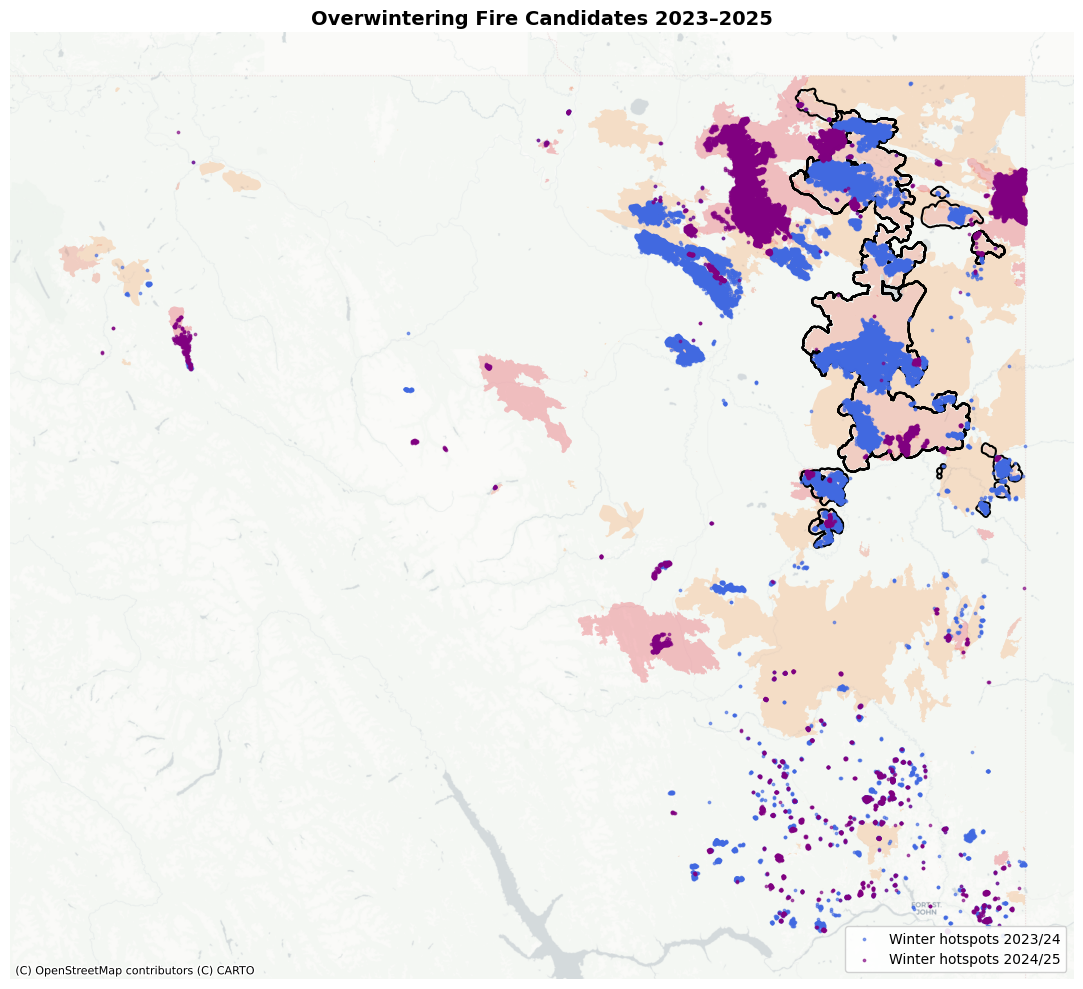

In [115]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.patches import Patch

perimeters_2023= gpd.read_file("../data/processed_fire_perimeters/perims_2023_clipped_3005.geojson")

# Reproject to Web Mercator for contextily basemap
perimeters_2023_wm    = perimeters_2023.to_crs(epsg=3857)
perimeters_2024_wm    = perimeters_2024.to_crs(epsg=3857)
perimeters_2025_wm    = perimeters_2025.to_crs(epsg=3857)
two_winter_wm         = two_winter_confirmed.to_crs(epsg=3857)
hs_winter_2023_24_wm  = hs_winter_2023_24.to_crs(epsg=3857)
hs_winter_2024_25_wm  = hs_winter_2024_25.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 10))

# Background perimeters — all years, muted
perimeters_2023_wm.plot(ax=ax, color='#f4a261', alpha=0.3, label='2023 perimeters')
perimeters_2024_wm.plot(ax=ax, color='#e76f51', alpha=0.3, label='2024 perimeters')
perimeters_2025_wm.plot(ax=ax, color='#e63946', alpha=0.3, label='2025 perimeters')

# Two-winter survivor origin perimeters — highlighted
two_winter_wm.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5, 
                   label='Two-winter survivor (2023 origin)')

# Winter hotspots
hs_winter_2023_24_wm.plot(ax=ax, color='royalblue', markersize=3, 
                            alpha=0.6, label='Winter hotspots 2023/24')
hs_winter_2024_25_wm.plot(ax=ax, color='purple', markersize=3, 
                            alpha=0.6, label='Winter hotspots 2024/25')

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

# Legend & labels
ax.set_title('Overwintering Fire Candidates 2023–2025', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('overwinter_map.png', dpi=300, bbox_inches='tight')
plt.show()

for each fire

In [119]:
# Merge stats from two_winter_gdf into two_winter_confirmed
two_winter_confirmed = two_winter_confirmed.merge(
    two_winter_gdf[['FIRE_NO_2023', 'FIRE_NO_2024',
                    'w1_detections', 'w1_satellites', 'w1_first', 'w1_last',
                    'w2_detections', 'w2_satellites', 'w2_first', 'w2_last',
                    'detection_span_days_w1', 'detection_span_days_w2']],
    on=['FIRE_NO_2023', 'FIRE_NO_2024'],
    how='left'
)

In [120]:
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Output folder
map_dir = Path("overwinter_fire_maps")
map_dir.mkdir(exist_ok=True)

def plot_fire_map(fire_no_2023, fire_no_2024, fire_no_2025):
    """
    Generate a detailed map for a single two-winter survivor fire.
    """

    # --- Subset all layers to this fire ---
    perim_2023 = perimeters_2023[perimeters_2023['FIRE_NO'] == fire_no_2023].to_crs(epsg=3857)
    perim_2024 = perimeters_2024[perimeters_2024['FIRE_NO'] == fire_no_2024].to_crs(epsg=3857)
    perim_2025 = perimeters_2025[perimeters_2025['FIRE_NO'] == fire_no_2025].to_crs(epsg=3857)

    buf_2023 = buffers_2023[buffers_2023['FIRE_NO'] == fire_no_2023].to_crs(epsg=3857)
    buf_2024 = buffers_2024[buffers_2024['FIRE_NO'] == fire_no_2024].to_crs(epsg=3857)

    # Hotspots that were joined to this fire
    hs_w1 = hs_winter_2023_24[
        hs_winter_2023_24.index.isin(
            join[join['FIRE_NO'] == fire_no_2023].index
        )
    ].to_crs(epsg=3857)

    hs_w2 = hs_winter_2024_25[
        hs_winter_2024_25.index.isin(
            join_2024_25[join_2024_25['FIRE_NO_2024'] == fire_no_2024].index
        )
    ].to_crs(epsg=3857)

    # --- Compute map extent from 2023 buffer + padding ---
    bounds = buf_2023.total_bounds  # [minx, miny, maxx, maxy]
    padding = 5000  # metres in 3857 (approx)
    minx, miny, maxx, maxy = bounds
    minx -= padding; miny -= padding
    maxx += padding; maxy += padding

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 10))

    # Buffers — dashed outline only
    if not buf_2023.empty:
        buf_2023.plot(ax=ax, color='none', edgecolor='#f4a261',
                      linestyle='--', linewidth=1.2, label='2023 buffer (1000m)')
    if not buf_2024.empty:
        buf_2024.plot(ax=ax, color='none', edgecolor='#e76f51',
                      linestyle='--', linewidth=1.2, label='2024 buffer (1000m)')

    # Fire perimeters — filled
    if not perim_2023.empty:
        perim_2023.plot(ax=ax, color='#f4a261', alpha=0.4,
                        edgecolor='#f4a261', linewidth=1.5, label='2023 perimeter')
    if not perim_2024.empty:
        perim_2024.plot(ax=ax, color='#e76f51', alpha=0.4,
                        edgecolor='#e76f51', linewidth=1.5, label='2024 perimeter')
    if not perim_2025.empty:
        perim_2025.plot(ax=ax, color='#e63946', alpha=0.4,
                        edgecolor='#e63946', linewidth=1.5, label='2025 perimeter')

    # Winter hotspots
    if not hs_w1.empty:
        hs_w1.plot(ax=ax, color='royalblue', markersize=15,
                   alpha=0.8, zorder=5, label=f'Winter hotspots 2023/24 (n={len(hs_w1)})')
    if not hs_w2.empty:
        hs_w2.plot(ax=ax, color='purple', markersize=15,
                   alpha=0.8, zorder=5, label=f'Winter hotspots 2024/25 (n={len(hs_w2)})')

    # Set extent
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

    # --- Annotation box with fire stats ---
    fire_row = two_winter_confirmed[
        two_winter_confirmed['FIRE_NO_2023'] == fire_no_2023
    ].iloc[0]

    stats_text = (
        f"FIRE_NO 2023: {fire_no_2023}\n"
        f"FIRE_NO 2024: {fire_no_2024}\n"
        f"FIRE_NO 2025: {fire_no_2025}\n"
        f"─────────────────────\n"
        f"Winter 1 detections:  {fire_row['w1_detections']}  ({fire_row['w1_satellites']} satellites)\n"
        f"  {fire_row['w1_first'].date()} → {fire_row['w1_last'].date()}\n"
        f"Winter 2 detections:  {fire_row['w2_detections']}  ({fire_row['w2_satellites']} satellites)\n"
        f"  {fire_row['w2_first'].date()} → {fire_row['w2_last'].date()}"
    )

    ax.text(0.02, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85))

    # Labels
    ax.set_title(
        f'Two-Winter Survivor: {fire_no_2023} → {fire_no_2024} → {fire_no_2025}',
        fontsize=13, fontweight='bold', pad=12
    )
    ax.legend(loc='lower right', framealpha=0.9, fontsize=8)
    ax.set_axis_off()

    plt.tight_layout()
    fname = map_dir / f"fire_{fire_no_2023}_{fire_no_2024}_{fire_no_2025}.png"
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


# --- Run for all two-winter survivors ---
for _, row in two_winter_confirmed.iterrows():
    plot_fire_map(
        fire_no_2023=row['FIRE_NO_2023'],
        fire_no_2024=row['FIRE_NO_2024'],
        fire_no_2025=row['FIRE_NO_2025']
    )

print(f"\nDone — {len(two_winter_confirmed)} maps saved to '{map_dir}/'")

Saved: overwinter_fire_maps/fire_G92498_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G91313_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G92940_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G91494_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G90288_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G93291_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G90980_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G90273_G80270_G90425.png
Saved: overwinter_fire_maps/fire_G83130_G80270_G90425.png
Saved: overwinter_fire_maps/fire_G93102_G90686_G90216.png
Saved: overwinter_fire_maps/fire_G91534_G90399_G90382.png
Saved: overwinter_fire_maps/fire_G90628_G80286_G90428.png

Done — 12 maps saved to 'overwinter_fire_maps/'


In [121]:
fire_no_2023 = 'G93291'
fire_no_2024 = 'G90228'
fire_no_2025 = 'G80320'

# Check each layer
print("2023 perim:", len(perimeters_2023[perimeters_2023['FIRE_NO'] == fire_no_2023]))
print("2024 perim:", len(perimeters_2024[perimeters_2024['FIRE_NO'] == fire_no_2024]))
print("2025 perim:", len(perimeters_2025[perimeters_2025['FIRE_NO'] == fire_no_2025]))

# Check winter 2 hotspot dates and location
hs_w2_check = hs_winter_2024_25[
    hs_winter_2024_25.index.isin(
        join_2024_25[join_2024_25['FIRE_NO_2024'] == fire_no_2024].index
    )
]
print("\nWinter 2 hotspot date range:")
print(hs_w2_check['date'].min(), "→", hs_w2_check['date'].max())
print("Winter 2 hotspot bounds:")
print(hs_w2_check.total_bounds)
print("2024 buffer bounds:")
print(buffers_2024[buffers_2024['FIRE_NO'] == fire_no_2024].total_bounds)

2023 perim: 1
2024 perim: 1
2025 perim: 1

Winter 2 hotspot date range:
2024-10-05 00:00:00 → 2025-05-31 00:00:00
Winter 2 hotspot bounds:
[1240978.32739501 1491869.46496187 1327578.4739007  1644333.28603803]
2024 buffer bounds:
[1226193.901806 1484206.53829  1332405.1615   1660530.477412]


In [123]:
def plot_fire_map(fire_no_2023, fire_no_2024, fire_no_2025):

    # --- Subset all layers ---
    perim_2023 = perimeters_2023[perimeters_2023['FIRE_NO'] == fire_no_2023].to_crs(epsg=3857)
    perim_2024 = perimeters_2024[perimeters_2024['FIRE_NO'] == fire_no_2024].to_crs(epsg=3857)
    perim_2025 = perimeters_2025[perimeters_2025['FIRE_NO'] == fire_no_2025].to_crs(epsg=3857)
    buf_2023   = buffers_2023[buffers_2023['FIRE_NO'] == fire_no_2023].to_crs(epsg=3857)
    buf_2024   = buffers_2024[buffers_2024['FIRE_NO'] == fire_no_2024].to_crs(epsg=3857)

    hs_w1 = hs_winter_2023_24[
        hs_winter_2023_24.index.isin(
            join[join['FIRE_NO'] == fire_no_2023].index
        )
    ].to_crs(epsg=3857)

    hs_w2 = hs_winter_2024_25[
        hs_winter_2024_25.index.isin(
            join_2024_25[join_2024_25['FIRE_NO_2024'] == fire_no_2024].index
        )
    ].to_crs(epsg=3857)

    # --- Compute extent from ALL layers combined ---
    all_bounds = []
    for layer in [perim_2023, perim_2024, perim_2025, 
                  buf_2023, buf_2024, hs_w1, hs_w2]:
        if not layer.empty:
            all_bounds.append(layer.total_bounds)  # [minx, miny, maxx, maxy]

    import numpy as np
    all_bounds = np.array(all_bounds)
    minx = all_bounds[:, 0].min()
    miny = all_bounds[:, 1].min()
    maxx = all_bounds[:, 2].max()
    maxy = all_bounds[:, 3].max()

    # Add padding
    padding = 5000
    minx -= padding; miny -= padding
    maxx += padding; maxy += padding

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 10))

    if not buf_2023.empty:
        buf_2023.plot(ax=ax, color='none', edgecolor='#f4a261',
                      linestyle='--', linewidth=1.2, label='2023 buffer (1000m)')
    if not buf_2024.empty:
        buf_2024.plot(ax=ax, color='none', edgecolor='#e76f51',
                      linestyle='--', linewidth=1.2, label='2024 buffer (1000m)')

    if not perim_2023.empty:
        perim_2023.plot(ax=ax, color='#f4a261', alpha=0.4,
                        edgecolor='#f4a261', linewidth=1.5, label='2023 perimeter')
    if not perim_2024.empty:
        perim_2024.plot(ax=ax, color='#e76f51', alpha=0.4,
                        edgecolor='#e76f51', linewidth=1.5, label='2024 perimeter')
    if not perim_2025.empty:
        perim_2025.plot(ax=ax, color='#e63946', alpha=0.4,
                        edgecolor='#e63946', linewidth=1.5, label='2025 perimeter')

    if not hs_w1.empty:
        hs_w1.plot(ax=ax, color='royalblue', markersize=15, alpha=0.8,
                   zorder=5, label=f'Winter hotspots 2023/24 (n={len(hs_w1)})')
    if not hs_w2.empty:
        hs_w2.plot(ax=ax, color='purple', markersize=15, alpha=0.8,
                   zorder=5, label=f'Winter hotspots 2024/25 (n={len(hs_w2)})')

    # --- Set extent from combined bounds ---
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

    # --- Annotation box ---
    fire_row = two_winter_confirmed[
        two_winter_confirmed['FIRE_NO_2023'] == fire_no_2023
    ].iloc[0]

    stats_text = (
        f"FIRE_NO 2023: {fire_no_2023}\n"
        f"FIRE_NO 2024: {fire_no_2024}\n"
        f"FIRE_NO 2025: {fire_no_2025}\n"
        f"─────────────────────\n"
        f"Winter 1 detections:  {fire_row['w1_detections']}  ({fire_row['w1_satellites']} satellites)\n"
        f"  {fire_row['w1_first'].date()} → {fire_row['w1_last'].date()}\n"
        f"Winter 2 detections:  {fire_row['w2_detections']}  ({fire_row['w2_satellites']} satellites)\n"
        f"  {fire_row['w2_first'].date()} → {fire_row['w2_last'].date()}"
    )

    ax.text(0.02, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85))

    ax.set_title(
        f'Two-Winter Survivor: {fire_no_2023} → {fire_no_2024} → {fire_no_2025}',
        fontsize=13, fontweight='bold', pad=12
    )
    ax.legend(loc='lower right', framealpha=0.9, fontsize=8)
    ax.set_axis_off()

    plt.tight_layout()
    fname = map_dir / f"fire_{fire_no_2023}_{fire_no_2024}_{fire_no_2025}.png"
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


# Re-run for all survivors
for _, row in two_winter_confirmed.iterrows():
    plot_fire_map(
        fire_no_2023=row['FIRE_NO_2023'],
        fire_no_2024=row['FIRE_NO_2024'],
        fire_no_2025=row['FIRE_NO_2025']
    )

Saved: overwinter_fire_maps/fire_G92498_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G91313_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G92940_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G91494_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G90288_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G93291_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G90980_G90228_G80320.png
Saved: overwinter_fire_maps/fire_G90273_G80270_G90425.png
Saved: overwinter_fire_maps/fire_G83130_G80270_G90425.png
Saved: overwinter_fire_maps/fire_G93102_G90686_G90216.png
Saved: overwinter_fire_maps/fire_G91534_G90399_G90382.png
Saved: overwinter_fire_maps/fire_G90628_G80286_G90428.png


# Distance between

In [ ]:
overwinter_months = [10, 11, 12, 1, 2, 3, 4, 5]
hs_offseason2 = hotspots[hotspots['date'].dt.month.isin(overwinter_months)]
hs_offseason2.head()

In [ ]:
#normalize hs_offseanson confidence values
hs_offseason2['confidence_class'] = hs_offseason2['CONFIDENCE'].apply(normalize_confidence)
#filter for medium and high confidence
hs_offseason_filtered = hs_offseason2[hs_offseason2['confidence_class'].isin(['medium', 'high'])].copy()
print(hs_offseason_filtered['confidence_class'].value_counts())

confidence_class
medium    65515
high       8311
Name: count, dtype: int64


In [127]:
# Subset hotspots by year — use full year, not just winter window
hs_2023_all = hs_offseason_filtered[hs_offseason_filtered['year'] == 2023]
hs_2024_all = hs_offseason_filtered[hs_offseason_filtered['year'] == 2024]
hs_2025_all = hs_offseason_filtered[hs_offseason_filtered['year'] == 2025]

# Spatial join each year's hotspots to that year's buffers
# This tells us which hotspots belong to which fire
join_2023_all = gpd.sjoin(
    hs_2023_all, buffers_2023[['FIRE_NO', 'geometry']],
    how='inner', predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2023'})

join_2024_all = gpd.sjoin(
    hs_2024_all, buffers_2024[['FIRE_NO', 'geometry']],
    how='inner', predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2024'})

join_2025_all = gpd.sjoin(
    hs_2025_all, perimeters_2025[['FIRE_NO', 'geometry']],
    how='inner', predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2025'})

In [128]:
import pandas as pd
from shapely.geometry import LineString

results = []

for _, fire in two_winter_confirmed.iterrows():
    fn_2023 = fire['FIRE_NO_2023']
    fn_2024 = fire['FIRE_NO_2024']
    fn_2025 = fire['FIRE_NO_2025']

    # Subset hotspots for this specific fire
    hs_23 = join_2023_all[join_2023_all['FIRE_NO_2023'] == fn_2023].copy()
    hs_24 = join_2024_all[join_2024_all['FIRE_NO_2024'] == fn_2024].copy()
    hs_25 = join_2025_all[join_2025_all['FIRE_NO_2025'] == fn_2025].copy()

    # Skip if any year is missing hotspots
    if hs_23.empty or hs_24.empty or hs_25.empty:
        print(f"Skipping {fn_2023} — missing hotspots: "
              f"2023={len(hs_23)} 2024={len(hs_24)} 2025={len(hs_25)}")
        continue

    # Extract the 4 key hotspots
    last_2023  = hs_23.sort_values('date').iloc[-1]
    first_2024 = hs_24.sort_values('date').iloc[0]
    last_2024  = hs_24.sort_values('date').iloc[-1]
    first_2025 = hs_25.sort_values('date').iloc[0]

    # Euclidean distance in metres (CRS 3005 is metric)
    dist_23_24 = last_2023.geometry.distance(first_2024.geometry)
    dist_24_25 = last_2024.geometry.distance(first_2025.geometry)

    results.append({
        # Fire IDs
        'FIRE_NO_2023':       fn_2023,
        'FIRE_NO_2024':       fn_2024,
        'FIRE_NO_2025':       fn_2025,

        # Key dates
        'last_hs_2023_date':  last_2023['date'],
        'first_hs_2024_date': first_2024['date'],
        'last_hs_2024_date':  last_2024['date'],
        'first_hs_2025_date': first_2025['date'],

        # Days between last detection and first reactivation
        'days_dormant_23_24': (first_2024['date'] - last_2023['date']).days,
        'days_dormant_24_25': (first_2025['date'] - last_2024['date']).days,

        # Coordinates of key hotspots (in EPSG:3005)
        'last_2023_x':        last_2023.geometry.x,
        'last_2023_y':        last_2023.geometry.y,
        'first_2024_x':       first_2024.geometry.x,
        'first_2024_y':       first_2024.geometry.y,
        'last_2024_x':        last_2024.geometry.x,
        'last_2024_y':        last_2024.geometry.y,
        'first_2025_x':       first_2025.geometry.x,
        'first_2025_y':       first_2025.geometry.y,

        # Euclidean distances in metres
        'dist_m_23_24':       round(dist_23_24, 2),
        'dist_m_24_25':       round(dist_24_25, 2),

        # FRP at key hotspots (fire intensity)
        'last_2023_frp':      last_2023['FRP'],
        'first_2024_frp':     first_2024['FRP'],
        'last_2024_frp':      last_2024['FRP'],
        'first_2025_frp':     first_2025['FRP'],

        # Which satellite detected each key hotspot
        'last_2023_sat':      last_2023['SATELLITE'],
        'first_2024_sat':     first_2024['SATELLITE'],
        'last_2024_sat':      last_2024['SATELLITE'],
        'first_2025_sat':     first_2025['SATELLITE'],
    })

distance_df = pd.DataFrame(results)

print(f"Fires processed: {len(distance_df)}")
print(distance_df[[
    'FIRE_NO_2023',
    'last_hs_2023_date', 'first_hs_2024_date', 'days_dormant_23_24', 'dist_m_23_24',
    'last_hs_2024_date', 'first_hs_2025_date', 'days_dormant_24_25', 'dist_m_24_25'
]].to_string())

Skipping G91494 — missing hotspots: 2023=0 2024=21955 2025=855
Skipping G90288 — missing hotspots: 2023=0 2024=21955 2025=855
Skipping G93291 — missing hotspots: 2023=0 2024=21955 2025=855
Skipping G90980 — missing hotspots: 2023=0 2024=21955 2025=855
Skipping G93102 — missing hotspots: 2023=0 2024=59 2025=19366
Fires processed: 7
  FIRE_NO_2023 last_hs_2023_date first_hs_2024_date  days_dormant_23_24  dist_m_23_24 last_hs_2024_date first_hs_2025_date  days_dormant_24_25  dist_m_24_25
0       G92498        2023-10-20         2024-04-11                 174      53719.29        2024-10-16         2025-05-05                 201     148981.44
1       G91313        2023-11-02         2024-04-11                 161      76110.97        2024-10-16         2025-05-05                 201     148981.44
2       G92940        2023-10-20         2024-04-11                 174      35046.68        2024-10-16         2025-05-05                 201     148981.44
3       G90273        2023-12-29       

These may not be true overwintering fires:

- Skipping G91494 — missing hotspots: 2023=0 2024=21955 2025=855
- Skipping G90288 — missing hotspots: 2023=0 2024=21955 2025=855
- Skipping G93291 — missing hotspots: 2023=0 2024=21955 2025=855
- Skipping G90980 — missing hotspots: 2023=0 2024=21955 2025=855
- Skipping G93102 — missing hotspots: 2023=0 2024=59 2025=19366

So inspect 2023

In [130]:
# what is the earliest date and latest hotspot date for each fire in each year?
summary_2023_all = join_2023_all.groupby('FIRE_NO_2023').agg(
    first_hotspot = ('date', 'min'),
    last_hotspot  = ('date', 'max'),
    n_hotspots    = ('date', 'count')
).reset_index()

summary_2023_all

,FIRE_NO_2023,first_hotspot,last_hotspot,n_hotspots
0,G80190,2023-10-02,2023-10-02,3
1,G80280,2023-10-08,2023-12-14,78
2,G80291,2023-10-13,2023-11-12,2
3,G80641,2023-12-10,2023-12-10,1
4,G80913,2023-10-27,2023-12-26,13
5,G83130,2023-10-14,2023-10-20,2
6,G90207,2023-10-04,2023-11-02,30
7,G90259,2023-11-16,2023-11-17,5
8,G90273,2023-12-29,2023-12-29,6
9,G90628,2023-10-04,2023-10-20,29


In [131]:
# what is the earliest date and latest hotspot date for each fire in each year?
summary_2024_all = join_2024_all.groupby('FIRE_NO_2024').agg(
    first_hotspot = ('date', 'min'),
    last_hotspot  = ('date', 'max'),
    n_hotspots    = ('date', 'count')
).reset_index()

summary_2024_all

,FIRE_NO_2024,first_hotspot,last_hotspot,n_hotspots
0,G80016,2024-04-02,2024-04-02,2
1,G80036,2024-04-07,2024-04-07,1
2,G80155,2024-04-23,2024-04-23,1
3,G80162,2024-01-28,2024-01-28,1
4,G80188,2024-04-27,2024-10-16,8
5,G80262,2024-05-10,2024-05-31,425
6,G80270,2024-05-09,2024-05-31,3569
7,G80273,2024-04-01,2024-12-23,12
8,G80286,2024-05-09,2024-05-30,563
9,G80305,2024-01-25,2024-05-15,115
